### 傳統 ML 模型訓練與比較

In [191]:
import pandas as pd
import numpy as np
df = pd.read_csv('../data/cleaned_encoded_data.csv')
df.head(5)
df.isna().sum()


gender                       0
no_show                      0
icd                      36418
appointment_shift            0
age                       8691
                         ...  
appointment_year_2018        0
appointment_year_2019        0
appointment_year_2020        0
appointment_year_2021        0
appointment_year_2022        0
Length: 82, dtype: int64

In [192]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46634 entries, 0 to 46633
Data columns (total 82 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   gender                          46634 non-null  float64
 1   no_show                         46634 non-null  int64  
 2   icd                             10216 non-null  object 
 3   appointment_shift               46634 non-null  int64  
 4   age                             37943 non-null  float64
 5   under_12_years_old              46634 non-null  int64  
 6   over_60_years_old               46634 non-null  int64  
 7   patient_needs_companion         46634 non-null  int64  
 8   average_temp_day                45930 non-null  float64
 9   average_rain_day                45930 non-null  float64
 10  max_temp_day                    45930 non-null  float64
 11  max_rain_day                    45930 non-null  float64
 12  rainy_day_before                

In [155]:
# Split Features and Target
X = df.drop(columns=['no_show', 'icd'])
y = df['no_show']


In [156]:
# Train-Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42) # Stratify to maintain the distribution of the target variable in both train and test sets


### Model Training 
#### 1. Logistic Regression
#### 2. Decision Tree
#### 3. Random Forest 

In [157]:
### Start with Basic Logistic Regression Model 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve


In [158]:
# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [159]:
### Add Imputer and Missing indicators for missing values
from sklearn.impute import SimpleImputer, MissingIndicator
from sklearn.preprocessing import StandardScaler

# 首先創建缺失值指示器
missing_indicator = X_train['age'].isna().astype(int).values.reshape(-1, 1)
missing_indicator_test = X_test['age'].isna().astype(int).values.reshape(-1, 1)

# 創建和使用 imputer
imputer = SimpleImputer(strategy='mean')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

# 特徵縮放
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

# 將缺失值指示器與縮放後的特徵組合
X_train_final = np.hstack((missing_indicator, X_train_scaled))
X_test_final = np.hstack((missing_indicator_test, X_test_scaled))



In [160]:
# Fix Imbalance data using SMOTE
print("Before SMOTE:")
print(y_train.value_counts())

from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_final, y_train)

print("After SMOTE:")
print(y_train_balanced.value_counts())

Before SMOTE:
no_show
0    33579
1     3728
Name: count, dtype: int64
After SMOTE:
no_show
0    33579
1    33579
Name: count, dtype: int64


In [161]:
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_balanced, y_train_balanced)

LogisticRegression(max_iter=1000, random_state=42)

In [162]:
y_pred = logreg.predict(X_test_final)
y_pred_proba = logreg.predict_proba(X_test_final)[:, 1]

#### Evaluation Metrics:
1. Accuracy = (TP + TN) / (TP + FP + TN + FN) 
2. Precision = TP / (TP + FN) 
3. Recall = TP / (TP + EN) -> 成功預測出來的比例
4. F1 Score = 2 * (Precision + Recall) / (Precision + Recall) 
5. ROC AUC

In [163]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model(y_test, y_pred, y_pred_proba, model_name="Model"):
    # Calculate all metrics at once
    print(f"{model_name} Evaluation:")
    print(f"Precision: {precision_score(y_test, y_pred):.3f}")
    print(f"Recall:    {recall_score(y_test, y_pred):.3f}")
    print(f"F1 Score:  {f1_score(y_test, y_pred):.3f}")
    print(f"ROC AUC:   {roc_auc_score(y_test, y_pred_proba):.3f}\n")
    
    # Plot confusion matrix
    plt.figure(figsize=(6, 4))
    sns.heatmap(confusion_matrix(y_test, y_pred), 
                annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Show', 'Show'], 
                yticklabels=['No Show', 'Show'])
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    print(classification_report(y_test, y_pred))

Logistic Regression Evaluation:
Precision: 0.144
Recall:    0.608
F1 Score:  0.232
ROC AUC:   0.639



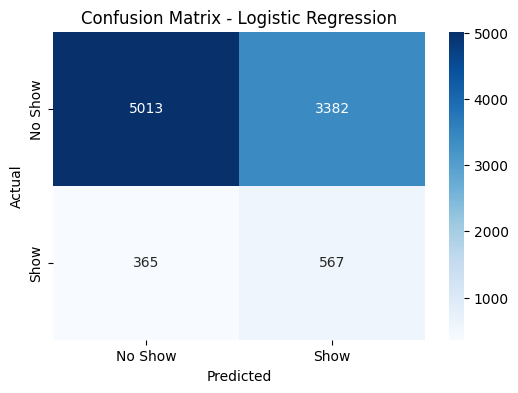

              precision    recall  f1-score   support

           0       0.93      0.60      0.73      8395
           1       0.14      0.61      0.23       932

    accuracy                           0.60      9327
   macro avg       0.54      0.60      0.48      9327
weighted avg       0.85      0.60      0.68      9327



In [164]:
evaluate_model(y_test, y_pred, y_pred_proba, "Logistic Regression")

### The performance of simple Logistric Regression is bad based on:
1. Low Precision 0.2 -> Of all predicted "no-shows", only 20% were truly no-shows
2. Low Recall 0.034 -> Model found only 3.4% of all actual no-shows
3. Low F1 Score  0.058 -> Balance between precision & recall — quite low
4. Low ROC AUC: 0.585 -> Barely better than random guessing (0.5 is random)

### Try Random Forest 

In [165]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,        # number of trees
    max_depth=None,          # allow trees to grow fully
    random_state=42,
    class_weight=None        # SMOTE already handled imbalance
)

rf_model.fit(X_train_balanced, y_train_balanced)


RandomForestClassifier(random_state=42)

In [166]:
y_pred_rf = rf_model.predict(X_test_final)
y_proba_rf = rf_model.predict_proba(X_test_final)[:, 1]  # needed for AUC

Random Forest Evaluation:
Precision: 0.361
Recall:    0.123
F1 Score:  0.184
ROC AUC:   0.743



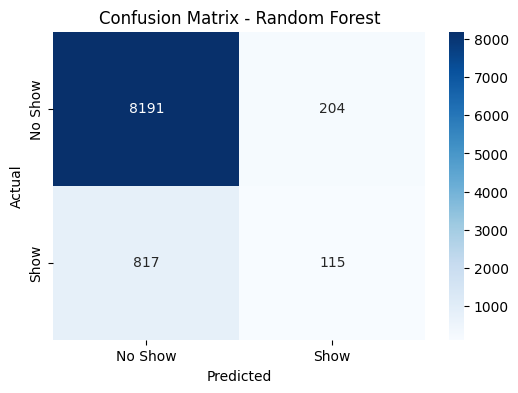

              precision    recall  f1-score   support

           0       0.91      0.98      0.94      8395
           1       0.36      0.12      0.18       932

    accuracy                           0.89      9327
   macro avg       0.63      0.55      0.56      9327
weighted avg       0.85      0.89      0.87      9327



In [167]:
evaluate_model(y_test, y_pred_rf, y_proba_rf, "Random Forest")


In [168]:
rf_model_2 = RandomForestClassifier(
    n_estimators=200,        # number of trees
    max_depth=None,          # allow trees to grow fully
    random_state=42,
    class_weight='balanced',        
    min_samples_split=2
)

rf_model_2.fit(X_train, y_train)
y_pred_rf = rf_model_2.predict(X_test)
y_proba_rf = rf_model_2.predict_proba(X_test)[:, 1]  # needed for AUC

Random Forest_Weighted Evaluation:
Precision: 0.378
Recall:    0.113
F1 Score:  0.174
ROC AUC:   0.777



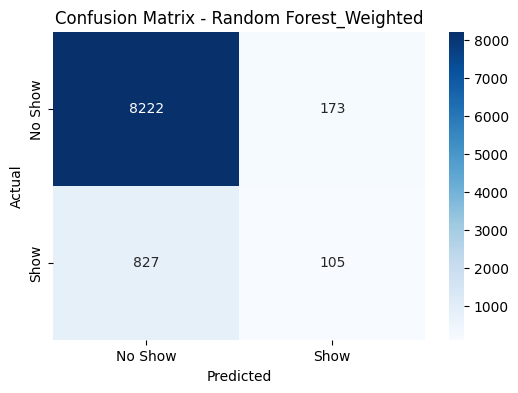

              precision    recall  f1-score   support

           0       0.91      0.98      0.94      8395
           1       0.38      0.11      0.17       932

    accuracy                           0.89      9327
   macro avg       0.64      0.55      0.56      9327
weighted avg       0.86      0.89      0.87      9327



In [169]:
evaluate_model(y_test, y_pred_rf, y_proba_rf, "Random Forest_Weighted")

In [170]:
threshold = 0.25
y_pred_custom = (y_proba_rf >= threshold).astype(int)
# Re-evaluate
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_custom))


              precision    recall  f1-score   support

           0       0.93      0.92      0.93      8395
           1       0.34      0.36      0.35       932

    accuracy                           0.87      9327
   macro avg       0.63      0.64      0.64      9327
weighted avg       0.87      0.87      0.87      9327



## Why Class Weights Worked Better
1. SMOTE creates synthetic examples that may not generalize well

2. Random Forest already does internal bootstrapping + averaging

3. Giving the model correct penalties via class weights is more elegant and stable



In [171]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [100, 200],         # number of trees
    'max_depth': [10, 20, None],        # how deep each tree can grow
    'min_samples_split': [2, 5],        # min samples to split a node
    'max_features': ['sqrt', 'log2']    # features per split
}
grid = GridSearchCV(rf_model, 
              param_grid,
              scoring='recall',
              cv=5, 
              n_jobs=-1, 
              verbose=2
              )

In [172]:
grid.fit(X_train_balanced, y_train_balanced)


Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV] END max_depth=10, max_features=sqrt, min_samples_split=2, n_estimators=100; total time=   4.3s
[CV] END max_depth=10, max_features=sqrt, min_samples_split=2, n_estimators=100; total time=   4.3s
[CV] END max_depth=10, max_features=sqrt, min_samples_split=2, n_estimators=100; total time=   4.4s
[CV] END max_depth=10, max_features=sqrt, min_samples_split=2, n_estimators=100; total time=   4.5s
[CV] END max_depth=10, max_features=sqrt, min_samples_split=2, n_estimators=100; total time=   4.6s
[CV] END max_depth=10, max_features=sqrt, min_samples_split=2, n_estimators=200; total time=   9.4s
[CV] END max_depth=10, max_features=sqrt, min_samples_split=2, n_estimators=200; total time=   9.4s
[CV] END max_depth=10, max_features=sqrt, min_samples_split=5, n_estimators=100; total time=   5.0s
[CV] END max_depth=10, max_features=sqrt, min_samples_split=2, n_estimators=200; total time=   9.5s
[CV] END max_depth=10, max_features=sq

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [10, 20, None],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='recall', verbose=2)

Best parameters: {'max_depth': None, 'max_features': 'log2', 'min_samples_split': 2, 'n_estimators': 200}
Random Forest_Best Evaluation:
Precision: 0.337
Recall:    0.114
F1 Score:  0.170
ROC AUC:   0.744



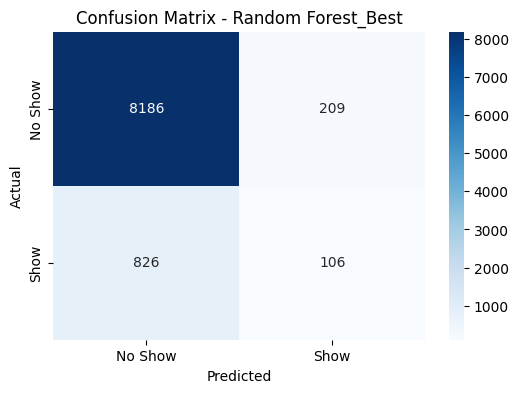

              precision    recall  f1-score   support

           0       0.91      0.98      0.94      8395
           1       0.34      0.11      0.17       932

    accuracy                           0.89      9327
   macro avg       0.62      0.54      0.56      9327
weighted avg       0.85      0.89      0.86      9327



In [173]:
best_rf = grid.best_estimator_

print("Best parameters:", grid.best_params_)

# Predict on test set
y_pred_best = best_rf.predict(X_test_final)
y_proba_best = best_rf.predict_proba(X_test_final)[:, 1]

# Evaluate
evaluate_model(y_test, y_pred_best, y_proba_best, "Random Forest_Best")


In [174]:
# Predict probabilities
y_proba = best_rf.predict_proba(X_test_final)[:, 1]

# Set a custom threshold (e.g., 0.3 instead of 0.5)
threshold = 0.30
y_pred_custom = (y_proba >= threshold).astype(int)

# Re-evaluate
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       0.92      0.92      0.92      8395
           1       0.29      0.30      0.30       932

    accuracy                           0.86      9327
   macro avg       0.61      0.61      0.61      9327
weighted avg       0.86      0.86      0.86      9327



### XGBoost

In [175]:
import xgboost as xgb

In [176]:
# Compute ratio: (negative class / positive class)
ratio = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight:", ratio)


scale_pos_weight: 9.007242489270386


In [177]:
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=ratio,    
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train, y_train)


/Users/ianwu/Desktop/NEU/Maching_Learning/ML_Project/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:44:14] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

XGBoost Evaluation:
Precision: 0.203
Recall:    0.609
F1 Score:  0.304
ROC AUC:   0.739



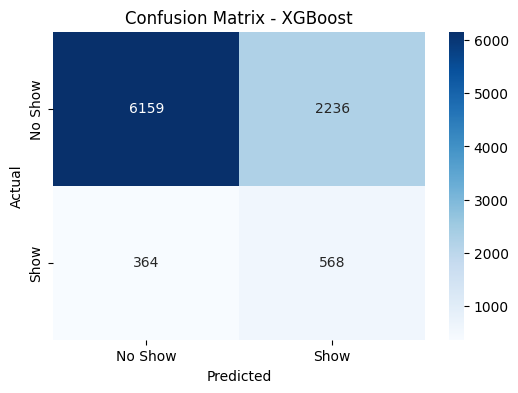

              precision    recall  f1-score   support

           0       0.94      0.73      0.83      8395
           1       0.20      0.61      0.30       932

    accuracy                           0.72      9327
   macro avg       0.57      0.67      0.56      9327
weighted avg       0.87      0.72      0.77      9327



In [178]:
y_pred = xgb_model.predict(X_test)
y_proba = xgb_model.predict_proba(X_test)[:, 1]

evaluate_model(y_test, y_pred, y_proba, "XGBoost")


In [179]:
threshold = 0.35
y_pred_custom = (y_proba >= threshold).astype(int)
print("Custom Threshold Report:")
print(classification_report(y_test, y_pred_custom))


Custom Threshold Report:
              precision    recall  f1-score   support

           0       0.97      0.45      0.61      8395
           1       0.15      0.86      0.25       932

    accuracy                           0.49      9327
   macro avg       0.56      0.65      0.43      9327
weighted avg       0.88      0.49      0.57      9327



## For Shows (Class 0):
1. Precision: 0.97 → 97% of patients predicted to show up actually showed up (improved)
2. Recall: 0.44 → Only 44% of actual show-ups were correctly identified (decreased)
3. F1-score: 0.61 → Moderate balanced performance for show-ups

## For No-shows (Class 1):
1. Precision: 0.15 → Only 15% of patients predicted to no-show actually didn't show up
2. Recall: 0.86 → 86% of actual no-shows were correctly identified (significantly improved)
3. F1-score: 0.25 → Still weak overall performance, but better at catching no-shows

In [180]:
## Fine Tuning XGBoost Model
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'min_child_weight': [1, 3],              # Add to prevent overfitting                    
    'reg_alpha': [0, 0.1, 1.0],                 # L1 regularization
    'reg_lambda': [0, 1.0, 5.0]                 # L2 regularization
}

xgb_clf = xgb.XGBClassifier(
    scale_pos_weight=ratio,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

# grid_search = GridSearchCV(
#     estimator=xgb_clf,
#     param_grid=param_grid,
#     scoring='recall',         # optimize for recall!
#     cv=3,
#     n_jobs=-1,
#     verbose=2
# )

from sklearn.model_selection import RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=xgb_clf,
    param_distributions=param_grid,
    n_iter=200,              # 只嘗試100種組合
    scoring='recall',
    cv=3,
    n_jobs=-1,
    verbose=2
)





In [ ]:
# grid_search.fit(X_train, y_train)
random_search.fit(X_train, y_train)

Best parameters: {'subsample': 0.8, 'reg_lambda': 1.0, 'reg_alpha': 1.0, 'n_estimators': 100, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.2, 'colsample_bytree': 0.8}
XGBoost_Best Evaluation:
Precision: 0.170
Recall:    0.613
F1 Score:  0.267
ROC AUC:   0.696



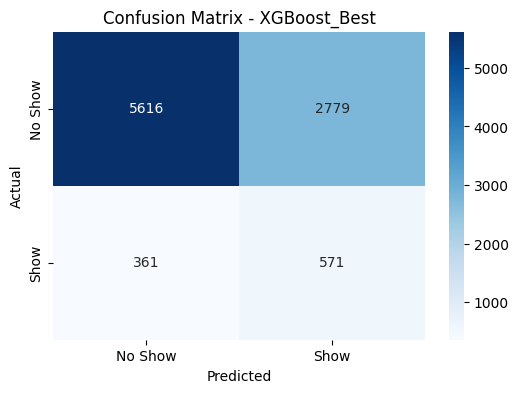

              precision    recall  f1-score   support

           0       0.94      0.67      0.78      8395
           1       0.17      0.61      0.27       932

    accuracy                           0.66      9327
   macro avg       0.56      0.64      0.52      9327
weighted avg       0.86      0.66      0.73      9327



In [182]:
best_xgb = random_search.best_estimator_

print("Best parameters:", random_search.best_params_)

# Predict and evaluate
y_pred_best = best_xgb.predict(X_test)
y_proba_best = best_xgb.predict_proba(X_test)[:, 1]

evaluate_model(y_test, y_pred_best, y_proba_best, "XGBoost_Best")


In [183]:
threshold = 0.40
y_pred_thresholded = (y_proba_best >= threshold).astype(int)

print("Threshold-Tuned Report:")
print(classification_report(y_test, y_pred_thresholded))


Threshold-Tuned Report:
              precision    recall  f1-score   support

           0       0.96      0.42      0.59      8395
           1       0.14      0.84      0.24       932

    accuracy                           0.47      9327
   macro avg       0.55      0.63      0.41      9327
weighted avg       0.88      0.47      0.55      9327



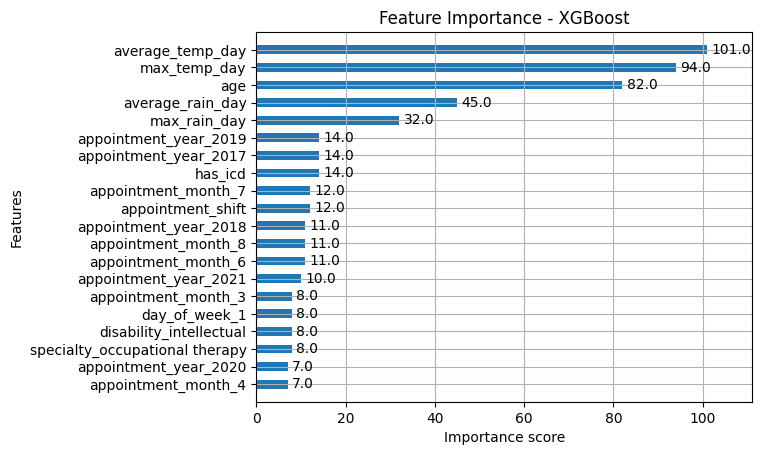

In [199]:
## Feature Importance
import matplotlib.pyplot as plt
xgb.plot_importance(best_xgb, max_num_features=20
                    , importance_type='weight', height=0.5)
plt.title('Feature Importance - XGBoost')
plt.show()

In [201]:
# Top features based on importance
top_features = [
    'max_temp_day', 'age', 'average_temp_day', 'average_rain_day', 'max_rain_day',
    'appointment_year_2019', 'appointment_year_2017', 'gender', 'appointment_month_6',
    'appointment_year_2018', 'appointment_month_8', 'appointment_month_5', 'has_icd',
    'appointment_shift', 'appointment_month_7', 'appointment_month_4', 'appointment_month_3', 'day_of_week_1','disability_intellectual', 'specialty_occupational therapy',
]

# Create a dataset with only top features
X_train_top = X_train[top_features]
X_test_top = X_test[top_features]

# Train model with just these features
xgb_top = xgb.XGBClassifier(
    scale_pos_weight=ratio,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

xgb_top.fit(X_train_top, y_train)

# Compare performance with full-feature model
y_pred_top = xgb_top.predict(X_test_top)
print(classification_report(y_test, y_pred_top))
y_proba_top = xgb_top.predict_proba(X_test_top)[:, 1]

/Users/ianwu/Desktop/NEU/Maching_Learning/ML_Project/venv/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [23:53:16] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       0.95      0.76      0.84      8395
           1       0.22      0.61      0.32       932

    accuracy                           0.74      9327
   macro avg       0.58      0.68      0.58      9327
weighted avg       0.87      0.74      0.79      9327



In [202]:
threshold = 0.30
y_pred_thresholded = (y_proba_top >= threshold).astype(int)

print("Threshold-Tuned Report:")
print(classification_report(y_test, y_pred_thresholded))


Threshold-Tuned Report:
              precision    recall  f1-score   support

           0       0.96      0.49      0.65      8395
           1       0.15      0.83      0.26       932

    accuracy                           0.53      9327
   macro avg       0.56      0.66      0.46      9327
weighted avg       0.88      0.53      0.61      9327



In [203]:
# Create interactions between top features
X_train_enhanced = X_train[top_features].copy()
X_test_enhanced = X_test[top_features].copy()

# Weather x Age interactions
X_train_enhanced['temp_age_interaction'] = X_train['max_temp_day'] * X_train['age']
X_test_enhanced['temp_age_interaction'] = X_test['max_temp_day'] * X_test['age']

X_train_enhanced['rain_age_interaction'] = X_train['average_rain_day'] * X_train['age']
X_test_enhanced['rain_age_interaction'] = X_test['average_rain_day'] * X_test['age']

# Month x Weather interactions
for month in ['appointment_month_6', 'appointment_month_7', 'appointment_month_8']:
    X_train_enhanced[f'{month}_temp'] = X_train[month] * X_train['max_temp_day']
    X_test_enhanced[f'{month}_temp'] = X_test[month] * X_test['max_temp_day']
    
    X_train_enhanced[f'{month}_rain'] = X_train[month] * X_train['average_rain_day']
    X_test_enhanced[f'{month}_rain'] = X_test[month] * X_test['average_rain_day']



In [ ]:
# Focus parameter grid on feature-related parameters
focused_param_grid = {
    'n_estimators': [200, 300],          # Reduced options
    'max_depth': [4, 6],                 # Reduced options
    'learning_rate': [0.05, 0.1],        # Smaller learning rates
    'colsample_bytree': [0.6, 0.7, 0.8], # Focus on feature sampling
    'subsample': [0.8, 0.9],             # Less row sampling variation
    'gamma': [0.1, 0.3, 0.5],            # More focus on feature split quality
    'min_child_weight': [1, 3]           # Fewer options
}

# Create model for grid search
xgb_focused = xgb.XGBClassifier(
    scale_pos_weight=ratio,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

# Run grid search
from sklearn.model_selection import StratifiedKFold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Grid search with custom metric focusing on recall
from sklearn.metrics import make_scorer, fbeta_score
custom_scorer = make_scorer(fbeta_score, beta=2)

grid_search_focused = GridSearchCV(
    estimator=xgb_focused,
    param_grid=focused_param_grid,
    scoring=custom_scorer,
    cv=cv,
    n_jobs=-1,
    verbose=2
)

# Fit on enhanced features dataset
grid_search_focused.fit(X_train_enhanced, y_train)

In [205]:
# Get best model from grid search
best_model = grid_search_focused.best_estimator_

y_pred_best = best_model.predict(X_test_enhanced)
# Get predicted probabilities
y_proba = best_model.predict_proba(X_test_enhanced)[:, 1]


# Print classification report
print(classification_report(y_test, y_pred_best))

# Try different thresholds to find optimal business value
thresholds = np.arange(0.1, 0.5, 0.05)
results = []

for threshold in thresholds:
    y_pred_threshold = (y_proba >= threshold).astype(int)
    
    # Get metrics
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_threshold).ravel()
    
    # Calculate business metrics
    # Assuming missed no-show costs $200, false intervention costs $20
    no_show_cost = 200 # Cost for actual no-show 
    intervention_cost = 20 # Cost to remind the patient throung sms or mail
    
    # Calculate cost savings = (true positives * no-show cost) - ((false positives + true positives) * intervention cost)
    cost_savings = (tp * no_show_cost) - ((fp + tp) * intervention_cost)
    
    results.append({
        'threshold': threshold,
        'true_positives': tp,
        'false_positives': fp,
        'false_negatives': fn,
        'recall': tp / (tp + fn),
        'precision': tp / (tp + fp) if (tp + fp) > 0 else 0,
        'cost_savings': cost_savings
    })

# Convert to DataFrame for analysis
import pandas as pd
results_df = pd.DataFrame(results)
print(results_df)

# Find threshold with best cost savings
best_threshold = results_df.loc[results_df['cost_savings'].idxmax(), 'threshold']
print(f"Best threshold based on cost savings: {best_threshold}")

              precision    recall  f1-score   support

           0       0.95      0.76      0.85      8395
           1       0.23      0.62      0.33       932

    accuracy                           0.75      9327
   macro avg       0.59      0.69      0.59      9327
weighted avg       0.88      0.75      0.79      9327

   threshold  true_positives  false_positives  false_negatives    recall  \
0       0.10             905             7130               27  0.971030   
1       0.15             895             6421               37  0.960300   
2       0.20             865             5745               67  0.928112   
3       0.25             832             5029              100  0.892704   
4       0.30             786             4316              146  0.843348   
5       0.35             750             3725              182  0.804721   
6       0.40             692             3108              240  0.742489   
7       0.45             638             2523              294  0

In [206]:
# Print the best threshold and its classification report
print(f"Best threshold based on cost savings: {best_threshold}")
print(classification_report(y_test, y_pred_thresholded))

# Print the best threshold and its confusion matrix
print(f"Best threshold based on cost savings: {best_threshold}")
print(confusion_matrix(y_test, y_pred_thresholded))

Best threshold based on cost savings: 0.4500000000000001
              precision    recall  f1-score   support

           0       0.96      0.49      0.65      8395
           1       0.15      0.83      0.26       932

    accuracy                           0.53      9327
   macro avg       0.56      0.66      0.46      9327
weighted avg       0.88      0.53      0.61      9327

Best threshold based on cost savings: 0.4500000000000001
[[4122 4273]
 [ 155  777]]
